[[ 7.3851902e-07 -2.1156968e-04]
 [-2.6271755e-05  9.9999772e-04]
 [ 3.2511377e-07  5.2202238e-05]
 ...
 [ 3.5789675e-05 -4.2573278e-04]
 [ 3.1405889e-05 -9.2151843e-04]
 [ 2.7655760e-05  5.0885684e-04]]


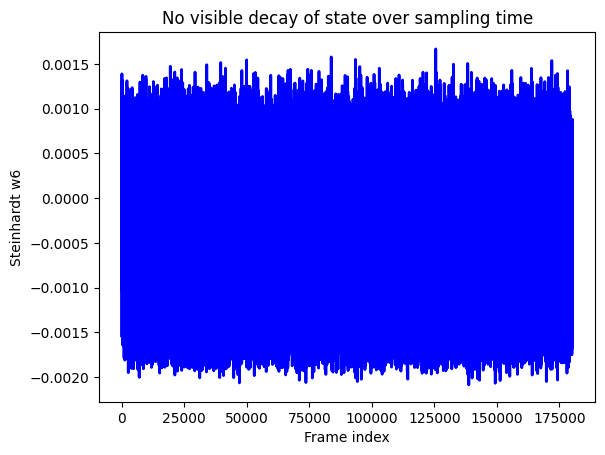

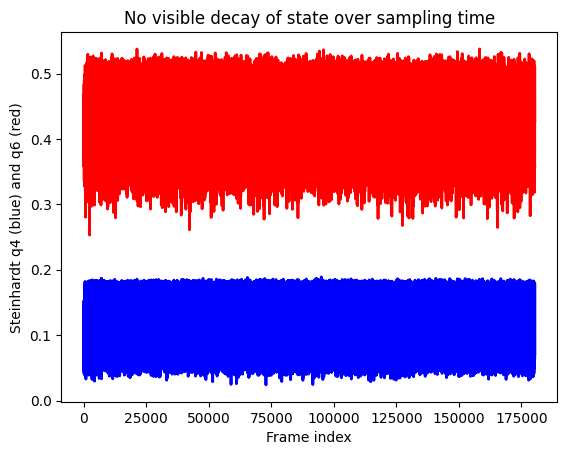

In [23]:
import numpy as np

dir="/home/karner/Documents/github/autoencode_statmech/autoencode_statmech/lammps/LJ/statistically_independent_samples/bcc"
data = np.load("{}/particle_data.npz".format(dir))
print(data["w4w6"])

import matplotlib.pyplot as plt

# plot w4 over time 
#plt.plot(data["w4w6"][:,0], c="r", lw=2)
# plot w6 over time 
plt.plot(data["w4w6"][:,1], c="b", lw=2)
plt.title("No visible decay of state over sampling time")
plt.xlabel("Frame index")
plt.ylabel("Steinhardt w6")
plt.show()

fig,ax = plt.subplots()
plt.plot(data["ql"][:,3], c="b", lw=2)
plt.plot(data["ql"][:,5], c="r", lw=2)
plt.xlabel("Frame index")
plt.ylabel("Steinhardt q4 (blue) and q6 (red)")
plt.title("No visible decay of state over sampling time")
plt.show()

[[-0.00052462 -0.00170707]
 [-0.00043495 -0.00132286]
 [-0.00053351 -0.00147661]
 ...
 [-0.00053582 -0.00183092]
 [-0.0005289  -0.00152873]
 [-0.00054333 -0.00167888]]


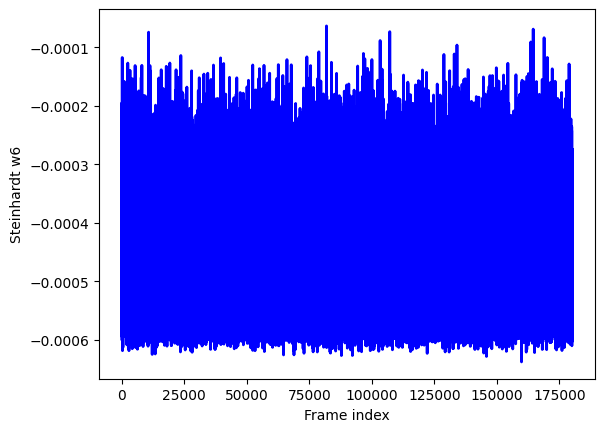

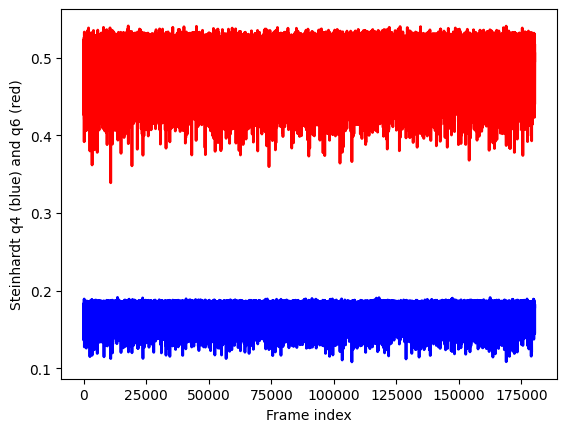

In [3]:
import numpy as np

dir="/home/karner/Documents/github/autoencode_statmech/autoencode_statmech/lammps/LJ/statistically_independent_samples/fcc"
data = np.load("{}/particle_data.npz".format(dir))
print(data["w4w6"])

import matplotlib.pyplot as plt

# plot w4 over time 
#plt.plot(data["w4w6"][:,0], c="r", lw=2)
# plot w6 over time 
plt.plot(data["w4w6"][:,0], c="b", lw=2)
plt.xlabel("Frame index")
plt.ylabel("Steinhardt w6")
plt.show()

fig,ax = plt.subplots()
plt.plot(data["ql"][:,3], c="b", lw=2)
plt.plot(data["ql"][:,5], c="r", lw=2)
plt.xlabel("Frame index")
plt.ylabel("Steinhardt q4 (blue) and q6 (red)")
plt.show()

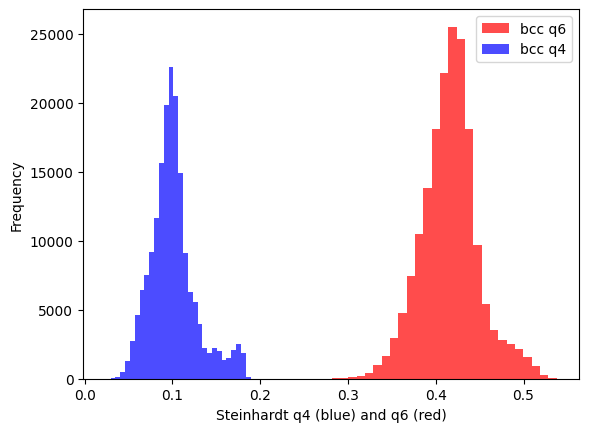

In [22]:
plt.hist(data["ql"][:,5], bins=30, color="r", alpha=0.7, label="bcc q6")
plt.hist(data["ql"][:,3], bins=30, color="b", alpha=0.7, label="bcc q4")
plt.xlabel("Steinhardt q4 (blue) and q6 (red)")
plt.ylabel("Frequency")
plt.legend()
plt.show()  

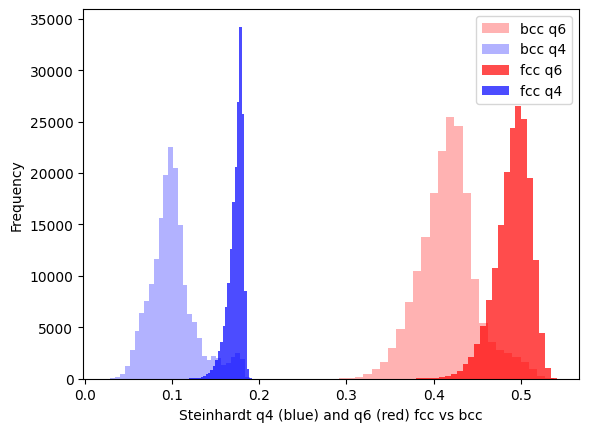

In [21]:
dir="/home/karner/Documents/github/autoencode_statmech/autoencode_statmech/lammps/LJ/statistically_independent_samples/fcc"
data_fcc = np.load("{}/particle_data.npz".format(dir))

plt.hist(data["ql"][:,5], bins=30, color="r", alpha=0.3, label="bcc q6")
plt.hist(data["ql"][:,3], bins=30, color="b", alpha=0.3, label="bcc q4")

plt.hist(data_fcc["ql"][:,5], bins=30, color="r", alpha=0.7, label="fcc q6")
plt.hist(data_fcc["ql"][:,3], bins=30, color="b", alpha=0.7, label="fcc q4")
plt.xlabel("Steinhardt q4 (blue) and q6 (red) fcc vs bcc")
plt.ylabel("Frequency")
plt.legend()
plt.show()  


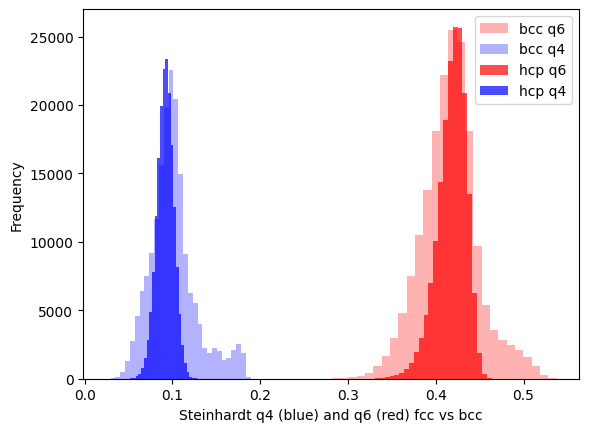

In [20]:
dir="/home/karner/Documents/github/autoencode_statmech/autoencode_statmech/lammps/LJ/statistically_independent_samples/hcp"
data_hcp = np.load("{}/particle_data.npz".format(dir))

plt.hist(data["ql"][:,5], bins=30, color="r", alpha=0.3,label="bcc q6")
plt.hist(data["ql"][:,3], bins=30, color="b", alpha=0.3, label="bcc q4")

plt.hist(data_hcp["ql"][:,5], bins=30, color="r", alpha=0.7, label="hcp q6")
plt.hist(data_hcp["ql"][:,3], bins=30, color="b", alpha=0.7, label="hcp q4")   
plt.xlabel("Steinhardt q4 (blue) and q6 (red) fcc vs bcc")
plt.ylabel("Frequency")
plt.legend(loc="best")
plt.show()  


In [4]:
dir="/home/karner/Documents/github/autoencode_statmech/autoencode_statmech/lammps/LJ/statistically_independent_samples/fcc"
data_fcc_seq = np.load("{}/particle_data_seq.npz".format(dir))

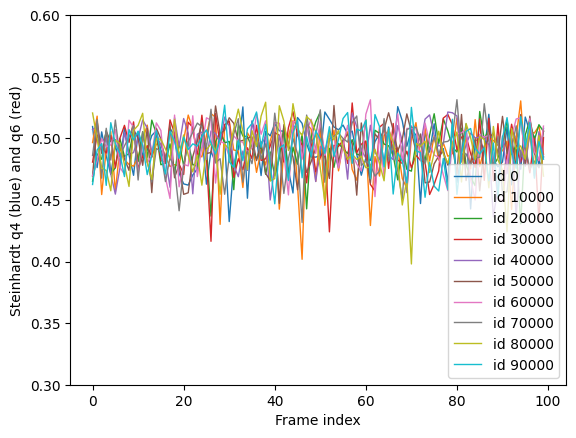

In [18]:
import matplotlib.pyplot as plt


fig,ax = plt.subplots()
for i in range(0, 100000, 10000):
    plt.plot(data_fcc_seq["ql"][:,i,5], lw=1, label="id {}".format(i))

plt.ylim(0.3, 0.6)
plt.xlabel("Frame index")
plt.ylabel("Steinhardt q4 (blue) and q6 (red)")
plt.legend()
plt.show()

In [23]:
q6 = data_fcc_seq["ql"][:, :, 5]                 # shape (T, N)

# particles that ever go below 0.4
mask = np.any(q6 < 0.38, axis=0)  # shape (N,)

# extract full trajectories for those particles
q6_bad_trajs = q6[:, mask]      # shape (T, N_bad)

In [45]:
q6 = data_fcc_seq["ql"][:, :, 5]             # (T, N)
thresh = 0.5
k = 15

below = (q6 > thresh)     # (T, N) boolean

# Running count of consecutive Trues along time axis
run = np.zeros_like(below, dtype=np.int32)
run[0] = below[0]
for t in range(1, below.shape[0]):
    run[t] = (run[t-1] + 1) * below[t]   # if below[t]=False -> 0, else increment

# Particles that ever reach a run length >= k
mask = np.any(run >= k, axis=0)
q6_selected = q6[:, mask]   # (T, N_selected)

q6_selected.shape

(100, 1)

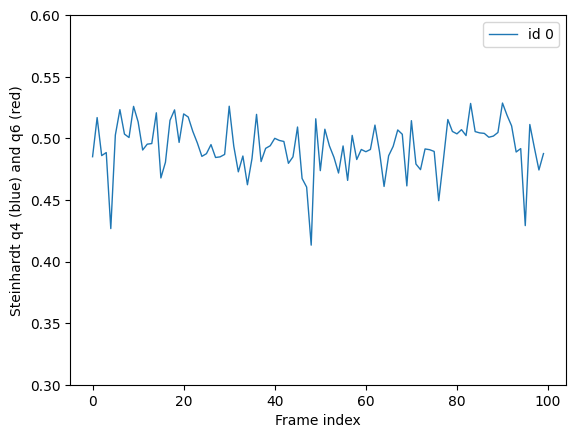

In [46]:
fig,ax = plt.subplots()
for i in range(len(q6_selected[0])):
    plt.plot(q6_selected[:,i], lw=1, label="id {}".format(i))

plt.ylim(0.3, 0.6)
plt.xlabel("Frame index")
plt.ylabel("Steinhardt q4 (blue) and q6 (red)")
plt.legend()
plt.show()